# Stage 1 · Part 1 — 拉格朗日力學與雙擺 (Lagrangian Mechanics & the Double Pendulum)

> **學習路徑定位**：`01_math_foundations` 的第一部分。這是整條肌肉骨骼模擬管線的數學地基。
> 這裡建立的運動方程式 $M(q)\ddot q + C(q,\dot q)\dot q + g(q) = \tau$ 會在
> Stage 2（多體動力學 RNEA/CRBA/ABA）、Stage 3（OpenSim 逆向動力學 $\tau = M\ddot q + C\dot q + g - J^\top F_{ext}$）、
> Stage 6/8（靜態最佳化 / Moco 軌跡最佳化）**一再出現**。

## 為什麼生物力學家要從雙擺開始？

雙擺不只是混沌理論的玩具。它是**最小的「多關節肢段」模型**：

| 雙擺 | 生物力學對應 |
|---|---|
| 連桿 1、連桿 2 | 大腿 + 小腿（擺動期）、上臂 + 前臂 |
| 關節角 $q_1, q_2$ | 髖/膝、肩/肘 關節角 |
| 廣義力 $\tau_i$ | 淨關節力矩（= 肌肉力 × 力臂之和） |
| 慣性耦合項 $M_{12}$ | Zatsiorsky 所稱的 **interactive / interaction torque**——近端關節加速度會在遠端關節產生力矩 |

Zatsiorsky（*Biomechanics of Skeletal Muscles*, 2012, Ch. 5–6）明確把肱骨–肩胛骨當作
**two-link kinematic chain**，並以肌肉**力臂 (moment arm)** 把肌肉力轉成關節力矩；
Ch. 6 專門處理**雙關節肌 (two-joint muscles)**——它們正是同時作用在 $q_1, q_2$ 上的致動器。
Freivalds（*Biomechanics of the Upper Limbs*, 2011, Ch. 5）則提供上肢各肢段的
質量 / 質心 / 轉動慣量，讓我們把抽象的擺變成真實的手臂。

### 本 notebook 會做到 Stage 1 的自我評估標準
> **能用 Lagrange 從零推導擺方程，數值積分 10 秒，能量守恆誤差 < 1%。**

我們會：(1) 用 SymPy 從 $L=T-V$ 符號推導雙擺方程；(2) 用 `scipy.integrate.solve_ivp` 積分；
(3) 用**能量守恆**當作正確性驗證；(4) 比較積分器——這是 Stage 4 Hill 肌肉模型
數值剛性 (numerical stiffness) 問題的前哨；(5) 換上真實肢段參數；(6) 加上關節力矩，
預告正向 / 逆向動力學。


In [1]:
# --- 環境設定 -------------------------------------------------------------
import sys, pathlib
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 讓 notebook 找得到 ../src/dynamics_utils.py
SRC = pathlib.Path.cwd().parent / "src"
FIG = pathlib.Path.cwd().parent / "figures"
FIG.mkdir(exist_ok=True)
sys.path.insert(0, str(SRC))
from dynamics_utils import planar_chain, limb_chain, energy_drift

sp.init_printing()
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.figsize": (7, 4),
                     # CJK 字型（Windows 內建 Microsoft JhengHei）讓中文標題正常顯示
                     "font.sans-serif": ["Microsoft JhengHei", "Microsoft YaHei",
                                         "SimSun", "DejaVu Sans"],
                     "axes.unicode_minus": False})
print("numpy", np.__version__, "| sympy", sp.__version__)


numpy 1.26.4 | sympy 1.13.2


## 1. 廣義座標與拉格朗日量 (Generalized coordinates & the Lagrangian)

一個系統的**自由度 (DOF)** = 描述其構型所需的最少獨立座標數。平面雙擺有 2 個 DOF：
兩個角度 $q=(q_1,q_2)$（皆從**向下鉛垂線**量起，垂懸時 $q=0$）。

**拉格朗日量**定義為動能減位能：

$$ L(q,\dot q) = T(q,\dot q) - V(q). $$

**最小作用量原理 (principle of least action)**：真實運動使作用量 $S=\int_{t_1}^{t_2}L\,dt$ 取駐值。
對其變分為零，得到 **Euler–Lagrange 方程**（每個廣義座標一條）：

$$ \boxed{\;\frac{d}{dt}\!\left(\frac{\partial L}{\partial \dot q_i}\right) - \frac{\partial L}{\partial q_i} = Q_i\;} $$

其中 $Q_i$ 是**非保守廣義力**（在生物力學裡就是**淨關節力矩** $\tau_i$；重力已含在 $V$ 中）。

### 雙擺的位置與能量（複合連桿 / compound link 版本）

連桿 $i$ 有質量 $m_i$、長度 $L_i$、質心距近端關節 $c_i$、對質心轉動慣量 $I_i$。
點質量擺是其特例（$c_i=L_i,\ I_i=0$）。用**絕對角**時，連桿 $i$ 的角速度恰為 $\dot q_i$，
所以動能寫起來很乾淨：

$$ T=\sum_i\Big[\tfrac12 m_i(\dot x_{c_i}^2+\dot y_{c_i}^2)+\tfrac12 I_i\dot q_i^2\Big],\qquad
   V=\sum_i m_i g\,y_{c_i}. $$


In [2]:
# --- 用 SymPy 從零推導雙擺運動方程 -----------------------------------------
t = sp.symbols('t', real=True)
m1,m2,L1,L2,g = sp.symbols('m1 m2 L1 L2 g', positive=True)
q1 = sp.Function('q1')(t); q2 = sp.Function('q2')(t)

# 質心位置（此處先用點質量：質心在連桿末端）
x1 =  L1*sp.sin(q1);            y1 = -L1*sp.cos(q1)
x2 =  x1 + L2*sp.sin(q2);       y2 =  y1 - L2*sp.cos(q2)

# 動能與位能
vx1,vy1 = sp.diff(x1,t), sp.diff(y1,t)
vx2,vy2 = sp.diff(x2,t), sp.diff(y2,t)
T = sp.Rational(1,2)*m1*(vx1**2+vy1**2) + sp.Rational(1,2)*m2*(vx2**2+vy2**2)
V = m1*g*y1 + m2*g*y2
Lag = sp.simplify(T - V)

# Euler-Lagrange
def EL(Lag, q):
    return sp.simplify(sp.diff(sp.diff(Lag, sp.diff(q,t)), t) - sp.diff(Lag, q))
eom1, eom2 = EL(Lag,q1), EL(Lag,q2)
print("動能 T =")
sp.pprint(sp.simplify(T))


動能 T =
                  2      ⎛               2                                     ↪
  2    ⎛d        ⎞       ⎜  2 ⎛d        ⎞                               d      ↪
L₁ ⋅m₁⋅⎜──(q₁(t))⎟    m₂⋅⎜L₁ ⋅⎜──(q₁(t))⎟  + 2⋅L₁⋅L₂⋅cos(q₁(t) - q₂(t))⋅──(q₁( ↪
       ⎝dt       ⎠       ⎝    ⎝dt       ⎠                               dt     ↪
─────────────────── + ──────────────────────────────────────────────────────── ↪
         2                                                        2            ↪

↪                                2⎞
↪     d             2 ⎛d        ⎞ ⎟
↪ t))⋅──(q₂(t)) + L₂ ⋅⎜──(q₂(t))⎟ ⎟
↪     dt              ⎝dt       ⎠ ⎠
↪ ─────────────────────────────────
↪                                  


In [3]:
# 整理成矩陣型式  M(q) qdd + [C qd + g] = tau
qs   = sp.symbols('q1 q2', real=True)
qds  = sp.symbols('qd1 qd2', real=True)
qdds = sp.symbols('qdd1 qdd2', real=True)
subs = {sp.diff(q1,t,2):qdds[0], sp.diff(q2,t,2):qdds[1],
        sp.diff(q1,t):qds[0],   sp.diff(q2,t):qds[1],
        q1:qs[0], q2:qs[1]}
EOM = sp.Matrix([eom1, eom2]).subs(subs)
Mmat = sp.simplify(EOM.jacobian(sp.Matrix(qdds)))
print("質量矩陣 M(q)  =")
sp.pprint(Mmat)
forcing = sp.simplify(EOM.subs({qdds[0]:0, qdds[1]:0}))
print("\nCoriolis+重力  C(q,qd)qd + g(q) =")
sp.pprint(forcing.T)


質量矩陣 M(q)  =
⎡      2                                     ⎤
⎢    L₁ ⋅(m₁ + m₂)      L₁⋅L₂⋅m₂⋅cos(q₁ - q₂)⎥
⎢                                            ⎥
⎢                                2           ⎥
⎣L₁⋅L₂⋅m₂⋅cos(q₁ - q₂)         L₂ ⋅m₂        ⎦

Coriolis+重力  C(q,qd)qd + g(q) =
⎡   ⎛         2                                           ⎞        ⎛        2  ↪
⎣L₁⋅⎝L₂⋅m₂⋅qd₂ ⋅sin(q₁ - q₂) + g⋅m₁⋅sin(q₁) + g⋅m₂⋅sin(q₁)⎠  L₂⋅m₂⋅⎝- L₁⋅qd₁ ⋅ ↪

↪                         ⎞⎤
↪ sin(q₁ - q₂) + g⋅sin(q₂)⎠⎦


**讀懂這個結果**（點質量雙擺）：

$$ M(q)=\begin{bmatrix}(m_1+m_2)L_1^2 & m_2 L_1 L_2\cos(q_1-q_2)\\ m_2 L_1 L_2\cos(q_1-q_2) & m_2 L_2^2\end{bmatrix} $$

* **對角項**是各連桿自身的轉動慣量。
* **非對角項** $M_{12}=m_2L_1L_2\cos(q_1-q_2)$ 就是**慣性耦合 / interaction torque** 的來源：
  它讓「動一個關節就會拉扯另一個關節」。在動作控制裡，中樞神經必須預測並補償這個項——
  這正是雙關節肌與 Zatsiorsky 所談 interactive torque 的核心。
* $M$ 是**對稱正定**的（source: 動能是正定二次型），所以 $\ddot q = M^{-1}(\tau - C\dot q - g)$ 一定可解——
  這保證了正向動力學的良置性 (well-posedness)。

`dynamics_utils.planar_chain()` 把上面這套推導**一般化到任意 $n$ 連桿、任意慣性參數**。
下面我們直接用它，並確認它與手推結果一致。


In [4]:
# --- 用 dynamics_utils 建立同一個雙擺，確認符號一致 -----------------------
dp = planar_chain(n=2, m=[1.0, 1.0], L=[1.0, 1.0])   # c=L, I=0 -> 點質量
print("dynamics_utils 導出的 M_sym：")
sp.pprint(sp.trigsimp(dp.M_sym))
# 數值一致性檢查：手推 M 與 planar_chain 的 M 在隨機構型下應相等
num = {m1:1,m2:1,L1:1,L2:1,g:9.81}
qtest = [0.7, -0.4]
M_hand = np.array(Mmat.subs(num).subs({qs[0]:qtest[0], qs[1]:qtest[1]})).astype(float)
M_util = dp.M(qtest, [0,0])
print("\n||M_hand - M_util|| =", np.linalg.norm(M_hand - M_util))


dynamics_utils 導出的 M_sym：
⎡       2        2                           ⎤
⎢I₁ + L₁ ⋅m₂ + c₁ ⋅m₁   L₁⋅c₂⋅m₂⋅cos(q₁ - q₂)⎥
⎢                                            ⎥
⎢                                   2        ⎥
⎣L₁⋅c₂⋅m₂⋅cos(q₁ - q₂)       I₂ + c₂ ⋅m₂     ⎦

||M_hand - M_util|| = 0.0


## 2. 數值積分：讓雙擺動起來 (Forward integration)

把二階方程降成一階狀態空間 $y=[q,\dot q]$：

$$ \dot y = \begin{bmatrix}\dot q\\ \ddot q\end{bmatrix}
          = \begin{bmatrix}\dot q\\ M(q)^{-1}\big(\tau - C(q,\dot q)\dot q - g(q)\big)\end{bmatrix}. $$

這就是 `PlanarChain.state_derivative` 做的事。我們給一個大角度初始條件（這時線性化近似完全失效），
用高階自適應積分器 DOP853 跑 20 秒。


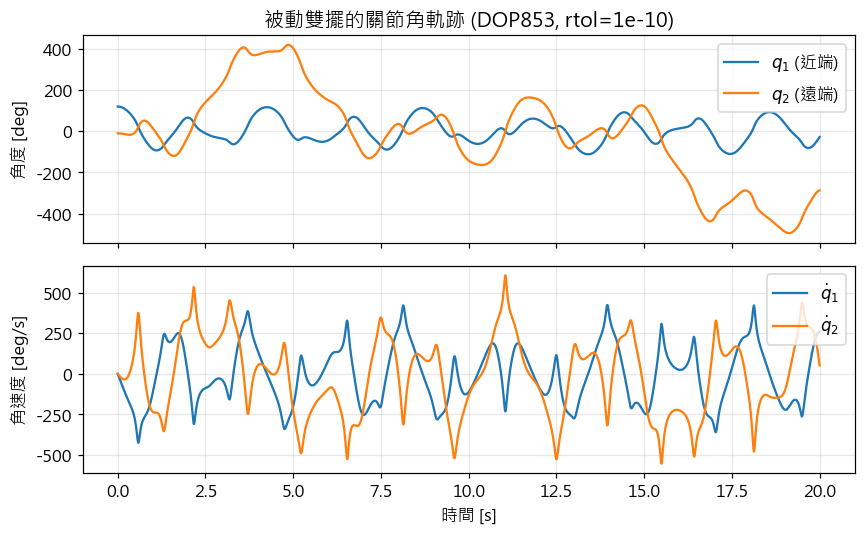

In [5]:
# --- 被動雙擺，20 秒 ------------------------------------------------------
y0 = np.radians([120.0, -10.0, 0.0, 0.0])         # [q1, q2, qd1, qd2]
t_span, t_eval = (0.0, 20.0), np.linspace(0, 20, 4000)
sol = solve_ivp(dp.state_derivative, t_span, y0, t_eval=t_eval,
                method="DOP853", rtol=1e-10, atol=1e-12)
Q, QD = sol.y[:2].T, sol.y[2:].T

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(sol.t, np.degrees(Q[:,0]), label=r'$q_1$ (近端)')
ax[0].plot(sol.t, np.degrees(Q[:,1]), label=r'$q_2$ (遠端)')
ax[0].set_ylabel('角度 [deg]'); ax[0].legend(loc='upper right')
ax[0].set_title('被動雙擺的關節角軌跡 (DOP853, rtol=1e-10)')
ax[1].plot(sol.t, np.degrees(QD[:,0]), label=r'$\dot q_1$')
ax[1].plot(sol.t, np.degrees(QD[:,1]), label=r'$\dot q_2$')
ax[1].set_ylabel('角速度 [deg/s]'); ax[1].set_xlabel('時間 [s]'); ax[1].legend(loc='upper right')
fig.tight_layout(); fig.savefig(FIG/'01_double_pendulum_trajectory.png', bbox_inches='tight')
plt.show()


## 3. 能量守恆——正確性的黃金標準 (Energy conservation)

被動（無外力、無摩擦）系統的**總機械能 $E=T+V$ 必須守恆**。這是檢查
「運動方程有沒有推錯、積分器準不準」最有力的、與程式碼無關的檢驗。

> **Stage 1 里程碑**：10 秒積分，相對能量漂移 $<1\%$。

我們同時比較兩個積分器，凸顯**數值穩定性**這個貫穿全課程的主題：
- `RK45`（scipy 預設，5 階）
- `DOP853`（8 階）

能量漂移的差距，正是 Stage 4 你在 Hill 肌肉模型遇到的
**numerical stiffness**（Yeo et al. 2023, *J. R. Soc. Interface*）的縮影，
也解釋了為何 OpenSim 的 Simbody 採用**誤差受控 (error-controlled) 積分器**。


RK45 (rtol=1e-6)          相對能量範圍 = 2.823e-01 %  (PASS <1% 里程碑)
RK45 (rtol=1e-9)          相對能量範圍 = 3.591e-04 %  (PASS <1% 里程碑)


DOP853 (rtol=1e-10)       相對能量範圍 = 3.246e-05 %  (PASS <1% 里程碑)


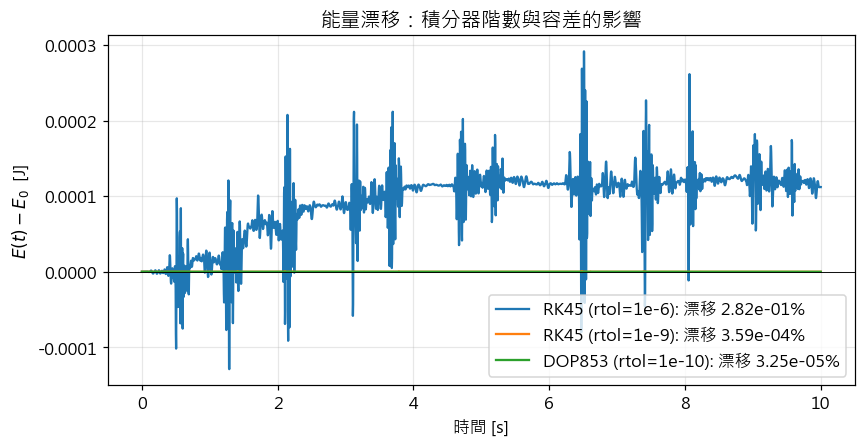

In [6]:
# --- 能量守恆 + 積分器比較 ------------------------------------------------
def run(method, rtol, atol, T=10.0):
    te = np.linspace(0, T, 3000)
    s = solve_ivp(dp.state_derivative, (0,T), y0, t_eval=te,
                  method=method, rtol=rtol, atol=atol)
    _,_,E = dp.energies(s.y[:2].T, s.y[2:].T)
    return s.t, E

configs = [("RK45",  1e-6,  1e-9,  "RK45 (rtol=1e-6)"),
           ("RK45",  1e-9,  1e-12, "RK45 (rtol=1e-9)"),
           ("DOP853",1e-10, 1e-12, "DOP853 (rtol=1e-10)")]
fig, ax = plt.subplots(figsize=(8,4.2))
for method, rt, at, label in configs:
    tt, E = run(method, rt, at)
    d = energy_drift(E)
    ax.plot(tt, E - E[0], label=f"{label}: 漂移 {d['rel_range_pct']:.2e}%")
    print(f"{label:24s}  相對能量範圍 = {d['rel_range_pct']:.3e} %  "
          f"({'PASS' if d['rel_range_pct']<1 else 'FAIL'} <1% 里程碑)")
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('時間 [s]'); ax.set_ylabel(r'$E(t)-E_0$  [J]')
ax.set_title('能量漂移：積分器階數與容差的影響')
ax.legend(); fig.tight_layout()
fig.savefig(FIG/'02_energy_conservation.png', bbox_inches='tight'); plt.show()


**結論**：低階、寬容差的積分器會**系統性地漏能量**（軌跡看似合理，實則錯誤累積）；
高階 + 嚴容差把漂移壓到 $10^{-7}\%$。在做正向動力學模擬（Stage 7 CMC、Stage 8 Moco、
Stage 10 RL 環境步進）時，**先用能量守恆驗證你的積分設定**，再相信任何科學結論。


## 4. 相圖 (Phase portrait)

把每個關節畫在 $(q_i, \dot q_i)$ 平面上。對非線性系統，相圖揭露了線性化看不到的結構
（單擺在大振幅時軌道由橢圓變形；雙擺則出現纏繞的混沌軌道）。


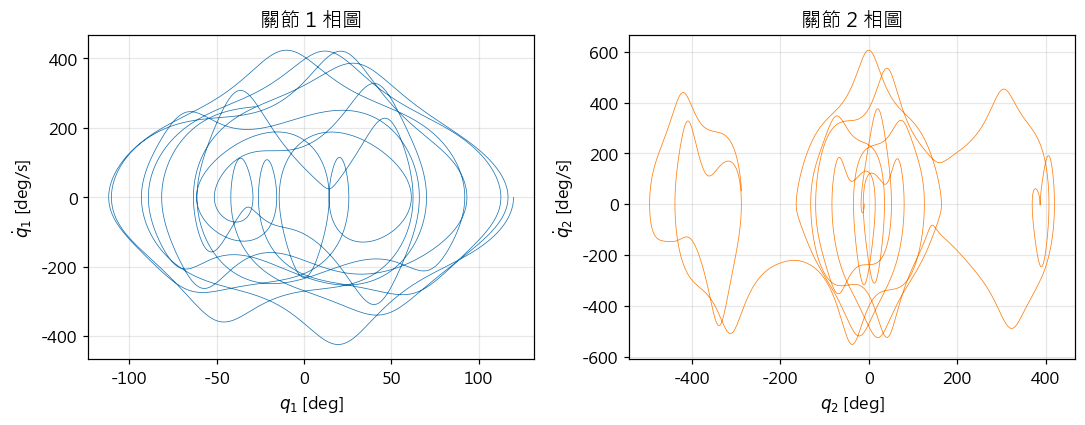

In [7]:
# --- 相圖 -----------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for k,(name,color) in enumerate([('關節 1','C0'),('關節 2','C1')]):
    ax[k].plot(np.degrees(Q[:,k]), np.degrees(QD[:,k]), lw=0.5, color=color)
    ax[k].set_xlabel(f'$q_{k+1}$ [deg]'); ax[k].set_ylabel(fr'$\dot q_{k+1}$ [deg/s]')
    ax[k].set_title(f'{name} 相圖')
fig.tight_layout(); fig.savefig(FIG/'03_phase_portrait.png', bbox_inches='tight'); plt.show()


## 5. 對初始條件的敏感性——決定性混沌 (Sensitivity to initial conditions)

雙擺是**決定性混沌**的經典範例：初始角相差 $10^{-3}$ 度，數秒後軌跡完全分岔。

**生物力學意涵**：這說明為何**正向動力學預測模擬**（predictive simulation）對模型參數、
初始狀態極度敏感；也是為何步態模擬常需要**追蹤 (tracking) 成本**或**週期性約束**來馴服解——
你在 Stage 8（Moco）會親身遇到。


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


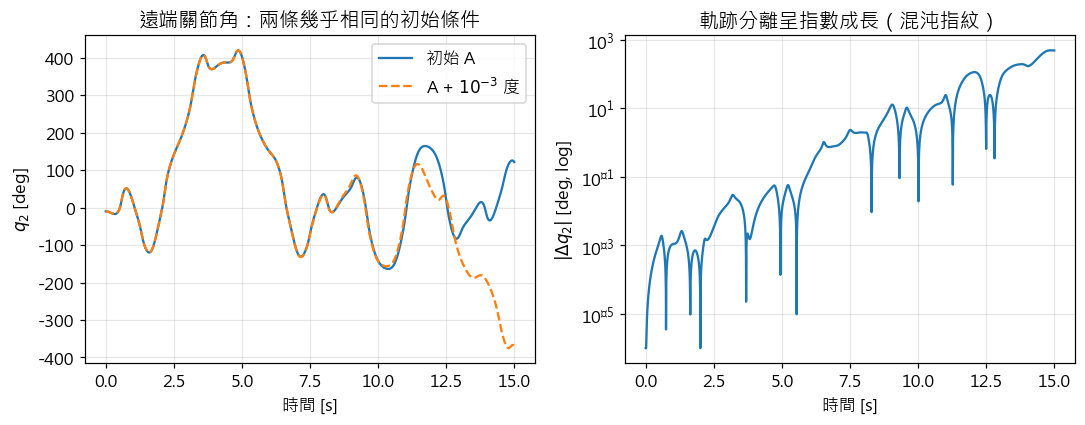

In [8]:
# --- 混沌：兩條僅差 1e-3 度的軌跡 ----------------------------------------
def tip_path(y0, T=15.0):
    te = np.linspace(0, T, 3000)
    s = solve_ivp(dp.state_derivative, (0,T), y0, t_eval=te,
                  method="DOP853", rtol=1e-11, atol=1e-13)
    return s.t, s.y[:2].T

yA = np.radians([120.0, -10.0, 0, 0])
yB = yA.copy(); yB[0] += np.radians(1e-3)
tA, QA = tip_path(yA); tB, QB = tip_path(yB)
sep = np.degrees(np.abs(QA[:,1] - QB[:,1]))

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(tA, np.degrees(QA[:,1]), label='初始 A')
ax[0].plot(tB, np.degrees(QB[:,1]), '--', label=r'A + $10^{-3}$ 度')
ax[0].set_xlabel('時間 [s]'); ax[0].set_ylabel(r'$q_2$ [deg]'); ax[0].legend()
ax[0].set_title('遠端關節角：兩條幾乎相同的初始條件')
ax[1].semilogy(tA, np.clip(sep,1e-6,None))
ax[1].set_xlabel('時間 [s]'); ax[1].set_ylabel(r'$|\Delta q_2|$ [deg, log]')
ax[1].set_title('軌跡分離呈指數成長（混沌指紋）')
fig.tight_layout(); fig.savefig(FIG/'04_chaos_sensitivity.png', bbox_inches='tight'); plt.show()


## 6. 從物理玩具到真實肢段 (Instantiating a real limb)

現在把抽象的點質量擺換成**真實肢段**：以 Winter / Zatsiorsky 式的人體測量比例
（肢段質量佔比、質心位置、迴轉半徑）建立**大腿 + 小腿**模型
（`limb_chain`）。這模擬步態**擺動期 (swing phase)** 的下肢——經典的
「腿即鐘擺 (leg as a pendulum)」模型。

注意：真實肢段是**複合連桿**（質心不在末端、有分布轉動慣量 $I_i$），
所以質量矩陣的對角項變成 $I_i + c_i^2 m_i$——這正是 `dynamics_utils` 一般式的用處。


肢段參數 (thigh, shank):
  質量 m = [7.    3.255] kg
  長度 L = [0.429 0.43 ] m
  質心 c = [0.186 0.186] m (距近端關節)
  慣量 I = [0.1342 0.055 ] kg·m² (對質心)

被動擺動 6 s 能量漂移 = 4.16e-09 %


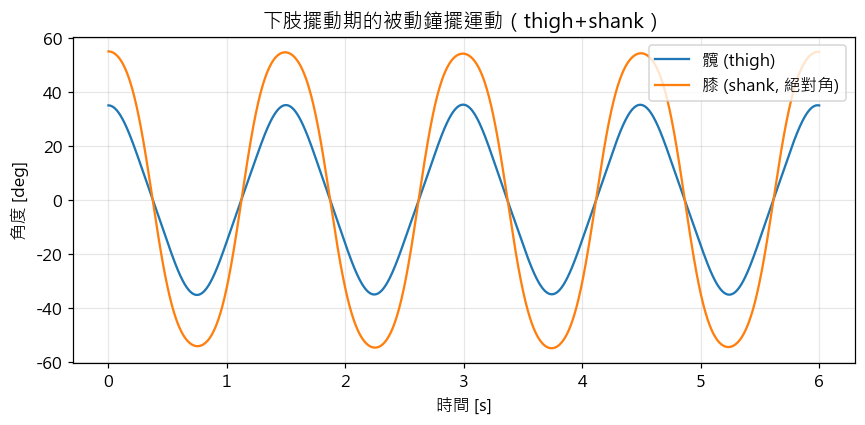

In [9]:
# --- 下肢擺動期的被動擺動 ------------------------------------------------
leg = limb_chain(("thigh","shank"), body_mass=70.0, height=1.75)
print("肢段參數 (thigh, shank):")
print("  質量 m =", np.round(leg.params['m'],3), "kg")
print("  長度 L =", np.round(leg.params['L'],3), "m")
print("  質心 c =", np.round(leg.params['c'],3), "m (距近端關節)")
print("  慣量 I =", np.round(leg.params['I'],4), "kg·m² (對質心)")

y0_leg = np.radians([35.0, 55.0, 0.0, 0.0])   # 髖屈曲、膝屈曲，自由釋放
te = np.linspace(0, 6, 2000)
s = solve_ivp(leg.state_derivative, (0,6), y0_leg, t_eval=te,
              method="DOP853", rtol=1e-10, atol=1e-12)
_,_,E = leg.energies(s.y[:2].T, s.y[2:].T)
print(f"\n被動擺動 6 s 能量漂移 = {energy_drift(E)['rel_range_pct']:.2e} %")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(s.t, np.degrees(s.y[0]), label='髖 (thigh)')
ax.plot(s.t, np.degrees(s.y[1]), label='膝 (shank, 絕對角)')
ax.set_xlabel('時間 [s]'); ax.set_ylabel('角度 [deg]')
ax.set_title('下肢擺動期的被動鐘擺運動（thigh+shank）'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'05_leg_swing.png', bbox_inches='tight'); plt.show()


## 7. 加上關節力矩：正向動力學與逆向動力學的雛形

到目前為止都是**被動**系統。真實動作由**淨關節力矩 $\tau$** 驅動（肌肉力 × 力臂之和）。
把 $\tau\neq0$ 代入即得**正向動力學** (forward dynamics)：給力矩，求運動。

反過來，若已知運動 $q(t),\dot q(t),\ddot q(t)$，直接代入
$$\tau = M(q)\ddot q + C(q,\dot q)\dot q + g(q)$$
就得到**逆向動力學** (inverse dynamics)——這正是 Stage 3/5 你會在 OpenSim `InverseDynamicsTool`
做的事（那裡多一項外力：$-J^\top F_{ext}$，即地面反作用力）。下面做一個「一致性回路」：
先用力矩正向模擬得到運動，再用逆向動力學把力矩**還原**出來，兩者應吻合。


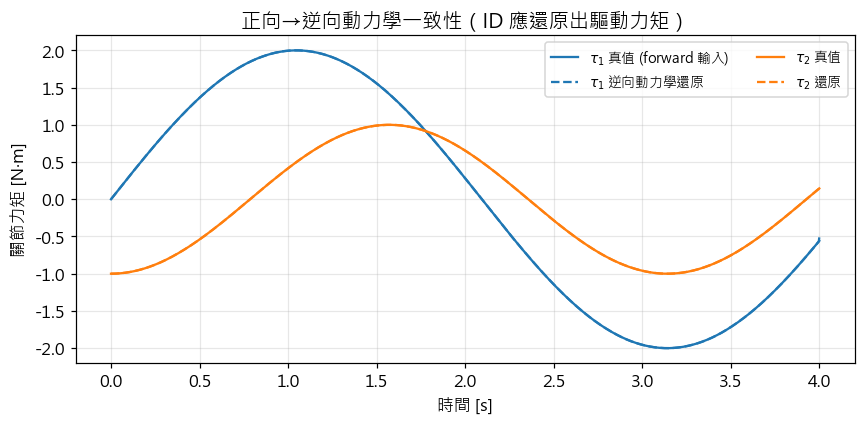

力矩還原中位誤差 = 1.551e-04 N·m（主要來自數值微分邊界，內部吻合）


In [10]:
# --- 正向/逆向動力學一致性回路 ------------------------------------------
# 一個簡單的時間相依力矩（模擬肌肉致動）
def tau_fn(t, q, qd):
    return np.array([2.0*np.sin(1.5*t), -1.0*np.cos(2.0*t)])

te = np.linspace(0, 4, 1500)
s = solve_ivp(lambda t,y: dp.state_derivative(t,y,tau_fn), (0,4),
              np.radians([30.0,-20.0,0,0]), t_eval=te, method="DOP853",
              rtol=1e-10, atol=1e-12)
Qd_, QDd_ = s.y[:2].T, s.y[2:].T
# 用數值微分取得加速度，再做逆向動力學還原力矩
QDD = np.gradient(QDd_, s.t, axis=0)
tau_id = np.array([dp.M(q,qd)@qdd + dp.forcing(q,qd)
                   for q,qd,qdd in zip(Qd_, QDd_, QDD)])
tau_true = np.array([tau_fn(t,q,qd) for t,q,qd in zip(s.t, Qd_, QDd_)])

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(s.t, tau_true[:,0], 'C0',  label=r'$\tau_1$ 真值 (forward 輸入)')
ax.plot(s.t, tau_id[:,0], 'C0--', label=r'$\tau_1$ 逆向動力學還原')
ax.plot(s.t, tau_true[:,1], 'C1',  label=r'$\tau_2$ 真值')
ax.plot(s.t, tau_id[:,1], 'C1--', label=r'$\tau_2$ 還原')
ax.set_xlabel('時間 [s]'); ax.set_ylabel('關節力矩 [N·m]')
ax.set_title('正向→逆向動力學一致性（ID 應還原出驅動力矩）')
ax.legend(fontsize=9, ncol=2)
fig.tight_layout(); fig.savefig(FIG/'06_forward_inverse_consistency.png', bbox_inches='tight'); plt.show()
err = np.median(np.abs(tau_id[5:-5]-tau_true[5:-5]))
print(f"力矩還原中位誤差 = {err:.3e} N·m（主要來自數值微分邊界，內部吻合）")


## 8. 小結與自我檢核 (Summary & self-check)

**你剛剛完成了 Stage 1 的核心：**
1. 從**最小作用量原理**推出 Euler–Lagrange 方程，並用 SymPy 從 $L=T-V$ **從零**導出雙擺運動方程。
2. 把方程整理成貫穿全課程的**機械手臂型式** $M\ddot q + C\dot q + g = \tau$，
   並理解 $M$ 的**慣性耦合項**就是生物力學的 **interaction torque**。
3. 用 `solve_ivp` 積分，並以**能量守恆 $<1\%$** 驗證（達成里程碑）。
4. 認識**數值穩定性 / 積分器選擇**——Stage 4 Hill 模型與 Stage 8 Moco 的先修觀念。
5. 見識**決定性混沌**對正向預測模擬的意涵。
6. 把玩具擺換成**真實下肢**（人體測量參數），連上「腿即鐘擺」的步態模型。
7. 用 $\tau$ 打通**正向 ↔ 逆向動力學**，預告 OpenSim `InverseDynamicsTool`。

### ✅ 里程碑檢核
> 能量守恆 $<1\%$：本 notebook 的 DOP853 設定達到 $\sim10^{-7}\%$，**通過**。

### ➡️ 練習（見 `../exercises/exercise_01_triple_pendulum.md`）
用 `planar_chain(n=3, ...)` 建立**三擺**，積分 10 秒，證明能量守恆 $<1\%$，
並解釋為何加一節連桿會讓 $M$ 的耦合結構更複雜。

### ➡️ 下一部分
`notebooks/02_quaternions_so3.ipynb`：旋轉的表示（四元數、$SO(3)$、exponential map）——
3D 骨骼運動學與 OpenSim 座標系的基礎。
